### Logic flow
* Generate stims, load into tensors
* Set up network architecture, loss functions/training structure, model eval 
* Train/test
* Visualize results: loss curves, response distribution, stim vs resp
* Formal test for responses being more tightly locked to context thant to true stim
* Save beh predictions, and hidden layer/embeddings/representations

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats, torch
from utils import plot_style, norm01; plot_style('poster');
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

from sklearn.decomposition import PCA
from matplotlib.colors import Normalize

variables and functions

In [2]:
def set_seed(seed: int):    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

seed = 0 # 20260309
conds, bounds = ['C1', 'C2', 'C3'], [0.25, 0.50, 0.75]

### 1. Generate stims, split into train/test, convert to tensors

generating unique trials

In [3]:
beh_df = pd.read_csv(f'../../inputs/psychopy/trials_patients_v2.csv', index_col=False)

# choose only 1st half of session, and every other trial
unique_trials_df = beh_df[:120][::2].copy().reset_index(drop=True)
assert len(unique_trials_df) == 60, "Expected 60 unique trials after filtering."

# renames
unique_trials_df = unique_trials_df.rename(columns={'stim_pos': 'stim', 'true_div': 'boundary'})
unique_trials_df['condition'] = unique_trials_df['condition'].map({'curv_comp': 'C1', 'baseline': 'C2', 'flat_comp': 'C3'})

# drops
unique_trials_df.drop(columns=['blockN', 'trial_key', 'noise_pos', 'shape', 'run', 'div_pos', 'stim_file_pos', 'target_pos', 'marker_init', 'shape_order', 'valence', 'target_file', 'img1_file', 'img2_file', 'valence_direction', 'direction', 'marker_direction', 'noise_direction', 'shape_category'], inplace=True)
unique_trials_df.reset_index(drop=True, inplace=True)

# adds
# cond_unique_stim_idx: groups rows by unique stimulus & condition
unique_trials_df['cond_unique_stim_idx'] = unique_trials_df.groupby('boundary')['stim'].transform(lambda x: pd.factorize(x)[0])
unique_trials_df['class'] = (unique_trials_df['stim'] > unique_trials_df['boundary']).astype(int)  # 0 or 1 based on stim vs boundary

# norm stim and boundary to 0-1 range
unique_trials_df['stim']     = np.round((unique_trials_df['stim']     + 0.4) / 0.8, 4)
unique_trials_df['boundary'] = np.round((unique_trials_df['boundary'] + 0.4) / 0.8, 4)

generated noised repeats of unique trials

In [4]:
# repeats
n_trial_reps, n_train, n_test, n_eval, trial_rep_noise = 14, 7, 3, 4, 0.1       # noise added to X_train tensors (regularization)
unique_trials_df['trial_id'] = unique_trials_df.index  # stim values can repeat within a condition, so an explicit id keeps all 60 trials distinct
all_trials_df = pd.concat([unique_trials_df.assign(rep=i) for i in range(n_trial_reps)], ignore_index=True)

# noise
rng = np.random.default_rng(seed)
all_trials_df['stim_noised'] = all_trials_df['stim'] + rng.normal(0, trial_rep_noise, size=len(all_trials_df))
# all_trials_df['boundary_noised'] = all_trials_df['boundary'] + rng.normal(0, trial_rep_noise, size=len(all_trials_df))

# show top row from each rep
all_trials_df.groupby('rep').first().reset_index()


,rep,condition,stim,boundary,cond_unique_stim_idx,class,trial_id,stim_noised
0,0,base,0.025,0.5,0,0,0,0.037573
1,1,base,0.025,0.5,0,0,0,-0.018644
2,2,base,0.025,0.5,0,0,0,0.103759
3,3,base,0.025,0.5,0,0,0,0.004548
4,4,base,0.025,0.5,0,0,0,0.154692
5,5,base,0.025,0.5,0,0,0,0.145326
6,6,base,0.025,0.5,0,0,0,-0.112520
7,7,base,0.025,0.5,0,0,0,-0.123965
8,8,base,0.025,0.5,0,0,0,0.079710
9,9,base,0.025,0.5,0,0,0,-0.002915


split into train/test/eval

In [5]:
all_trials_df['train/test'] = ''
train_idx, test_idx, eval_idx = [], [], []

# split each unique trial's reps into train/test/eval
for _, unique_combo in all_trials_df.groupby('trial_id'):
    combo_idxs = unique_combo.index.to_numpy().copy()
    np.random.default_rng(seed).shuffle(combo_idxs)
    test_idx.extend(combo_idxs[:n_test]); train_idx.extend(combo_idxs[n_test:n_test+n_train]); eval_idx.extend(combo_idxs[-n_eval:])  # last ones for eval

all_trials_df.loc[train_idx, 'train/test'] = 'train'; all_trials_df.loc[test_idx, 'train/test'] = 'test'; all_trials_df.loc[eval_idx, 'train/test'] = 'eval'
train_df = all_trials_df.loc[train_idx].reset_index(drop=True)
test_df = all_trials_df.loc[test_idx].reset_index(drop=True)
eval_df = all_trials_df.loc[eval_idx].reset_index(drop=True)
 
print(f'number of trials:\n# unique trials: {len(unique_trials_df)}\n# all trials: {len(all_trials_df)}\n# train trials: {len(train_df)}\n# test trials: {len(test_df)}\n# eval trials: {len(eval_df)}')
all_trials_df.groupby('rep').first().reset_index()


number of trials:
# unique trials: 60
# all trials: 840
# train trials: 420
# test trials: 180
# eval trials: 240


,rep,condition,stim,boundary,cond_unique_stim_idx,class,trial_id,stim_noised,train/test
0,0,base,0.025,0.5,0,0,0,0.037573,test
1,1,base,0.025,0.5,0,0,0,-0.018644,eval
2,2,base,0.025,0.5,0,0,0,0.103759,test
3,3,base,0.025,0.5,0,0,0,0.004548,test
4,4,base,0.025,0.5,0,0,0,0.154692,train
5,5,base,0.025,0.5,0,0,0,0.145326,train
6,6,base,0.025,0.5,0,0,0,-0.112520,train
7,7,base,0.025,0.5,0,0,0,-0.123965,train
8,8,base,0.025,0.5,0,0,0,0.079710,eval
9,9,base,0.025,0.5,0,0,0,-0.002915,eval


convert to tensors

In [6]:
# model always sees a noised stim (like subjects do); targets stay clean
def df_to_tensors(df):
    X = torch.tensor(df[['stim_noised', 'boundary']].values.copy(), dtype=torch.float32)
    y_class = torch.tensor(df[['class']].values.copy(), dtype=torch.float32)
    y_stim = torch.tensor(df[['stim']].values.copy(), dtype=torch.float32)
    return X, y_class, y_stim

X_train, y_class_train, y_stim_train = df_to_tensors(train_df)
X_test, y_class_test, y_stim_test = df_to_tensors(test_df)
X_eval, y_class_eval, y_stim_eval = df_to_tensors(eval_df)

print(f'train: X({X_train.shape}), y_class({y_class_train.shape}), y_stim({y_stim_train.shape})')
print(f'test: X({X_test.shape}), y_class({y_class_test.shape}), y_stim({y_stim_test.shape})')
print(f'eval: X({X_eval.shape}), y_class({y_class_eval.shape}), y_stim({y_stim_eval.shape})')

train: X(torch.Size([420, 2])), y_class(torch.Size([420, 1])), y_stim(torch.Size([420, 1]))
test: X(torch.Size([180, 2])), y_class(torch.Size([180, 1])), y_stim(torch.Size([180, 1]))
eval: X(torch.Size([240, 2])), y_class(torch.Size([240, 1])), y_stim(torch.Size([240, 1]))


### 2. network architecture, loss functions for train/test, model evaluation

architecture & parameters

In [7]:
# --- Architecture ---
class BoundaryNet(nn.Module):
    """
    2-input → 10-unit hidden → 1-output boundary network.
    Inputs   : [stim ∈ (0,1),  boundary ∈ {0.25, 0.50, 0.75}]
    Hidden   : 10 units, ReLU
    fc2_pos  : linear → graded position response
    """
    def __init__(self, in_dim: int = 2, hidden_dim: int = 10):
        super().__init__()
        self.fc2hidden = nn.Linear(in_dim, hidden_dim)
        self.fc2output = nn.Linear(hidden_dim, 1)

    def forward_with_hidden(self, x: torch.Tensor):
        """Return (position_output, hidden_activations) for analysis."""
        hidden = F.relu(self.fc2hidden(x))
        pos_pred = self.fc2output(hidden)
        return pos_pred, hidden

print('BoundaryNet defined.')
BoundaryNet()

lr = 1e-2
hypothesis= ['Generalizable', 'Reconfigurable', 'Generalizable & Reconfigurable'][2]
hypothesis_loss_wts = {'Generalizable': (1,0), 'Reconfigurable': (.45,.55), 'Generalizable & Reconfigurable': (.65,.35)}
mse_wt, context_wt = hypothesis_loss_wts[hypothesis]
class_acc_target = .85
min_epochs, max_epochs, conv_window = 15, 500, 20

BoundaryNet defined.


In [8]:
# # --- Architecture schematic: 2 inputs → 10 ReLU hidden → 1 positional output ---
# import matplotlib.pyplot as plt
# import numpy as np

# fig, ax = plt.subplots(figsize=(4,3))
# ax.set_aspect('equal'); ax.axis('off') # keeps nodes circular

# # layer x-positions and node y-positions
# x_in, x_hid, x_out = 0.0, 2.4, 4.8
# y_in, y_hid, y_out = [1.65, 3.35], np.linspace(0, 5.0, 10), 2.5
# c_in, c_hid, c_out = '#8497B0', '#C9C9C9', '#4E79A7'
# r = 0.17

# def node(x, y, color):    ax.add_patch(plt.Circle((x, y), r, facecolor=color, edgecolor='k', linewidth=1.2, zorder=3))

# # connections drawn first so nodes sit on top of them
# for yi in y_in:
#     for yh in y_hid:    ax.plot([x_in, x_hid], [yi, yh], color='0.75', lw=0.7, zorder=1)
# for yh in y_hid:
#     ax.plot([x_hid, x_out], [yh, y_out], color=c_out, lw=0.7, alpha=0.5, zorder=1)

# # nodes
# for yi in y_in:     node(x_in, yi, c_in)
# for yh in y_hid:    node(x_hid, yh, c_hid)
# node(x_out, y_out, c_out)

# # input / output labels
# ax.text(x_in - 0.35, y_in[1], 'Stimulus\n(0–1)', ha='right', va='center', fontsize=12)
# ax.text(x_in - 0.35, y_in[0], 'Context\n{0.25,\n0.50,\n0.75}', ha='right', va='center', fontsize=12)
# ax.text(x_out + 0.35, y_out, 'Response\n(0-1)', ha='left', va='center', fontsize=12, color=c_out)

# # layer titles
# # ax.text(x_in, 5.6, 'input\n(2)', ha='center', va='bottom', fontsize=13, fontweight='bold')
# ax.text(x_hid, 5.6, 'hidden\n(10, ReLU)', ha='center', va='bottom', fontsize=13, fontweight='bold')
# # ax.text(x_out, 5.6, 'output\n(1)', ha='center', va='bottom', fontsize=13, fontweight='bold')

# # ax.text((x_in + x_hid) / 2, -0.65, 'fc1', ha='center', fontsize=12, style='italic', color='0.35')

# # arrow from the response node down to the training losses, since the dual (stim + context) objective is central to the hypothesis
# ax.annotate('', xy=(x_out, y_out - 1.5), xytext=(x_out, y_out - r - 0.08),
#             arrowprops=dict(arrowstyle='-|>', color='0.25', lw=1.2))
# ax.text(x_out, y_out - 1.75,
#         r'$w_{stim}\,\mathrm{MSE}(resp,\ stim)$' + '\n' + r'$+\ w_{ctx}\,\mathrm{MSE}(resp,\ context)$',
#         ha='center', va='top', fontsize=9)

# ax.set_xlim(-2.2, 7.2); ax.set_ylim(-1.0, 6.7)
# fig.tight_layout()
# fig.savefig('../../outputs/figs/presentations/ccn/poster/network.svg', dpi=300, bbox_inches='tight')
# plt.show()


train/test setup

In [9]:
# full batch gradient descent (no dataloader) since dataset is small and we want to compute losses on all trials each epoch
def run_epoch(model, X, y_class, y_stim, optimizer=None):
    
    # if optimizer passed, we are in training mode, and gradients will be updated
    training = optimizer is not None
    model.train(training)

    with torch.set_grad_enabled(training):

        pos_preds, _ = model.forward_with_hidden(X)
        bounds = X[:, 1:2]

        mse_losses, context_losses = F.mse_loss(pos_preds, y_stim), F.mse_loss(pos_preds, bounds)
        # bce_losses, corr_losses = F.binary_cross_entropy_with_logits(pos_preds - bounds, y_class), correlation_loss(pos_preds, y_stim)
        total_losses = (mse_wt * mse_losses) + (context_wt * context_losses)# + (bce_wt * bce_losses) + (corr_wt * corr_losses)
        if training: optimizer.zero_grad(); total_losses.backward(); optimizer.step()

        n = X.size(0)
        # accuracy = correct side of the boundary, from the (single) positional head
        class_acc = ((pos_preds >= bounds).float() == y_class).sum().item()

    return {'total_losses':total_losses.item(), 'mse_losses':mse_losses.item(), 'context_losses': context_losses.item(), 'class_acc':class_acc / n}


inference setup

In [10]:
def evaluate_model_on_df(model, df):

    X_eval, y_class_eval, y_stim_eval = df_to_tensors(df)

    model.eval()
    with torch.no_grad():  pos_pred, hidden = model.forward_with_hidden(X_eval)

    pred_df = df.copy()
    pred_df['pos_pred']       = pos_pred.squeeze(1).numpy()
    pred_df['class_pred'] = (pos_pred.squeeze(1) >= X_eval[:, 1]).float().numpy()
    perform_metrics = run_epoch(model, X_eval, y_class_eval, y_stim_eval)

    return pred_df, hidden.numpy(), perform_metrics


### 3. Run model
per network, train/test -> inference -> save

In [11]:
n_nets = 30
all_nets_detailed_res = [] # 1 row per net

for net_idx in range(n_nets):

    set_seed(seed + net_idx)
    model = BoundaryNet(in_dim=2, hidden_dim=10)
    optimizer = Adam(model.parameters(), lr=lr)
    net_train_test_res, converged = [], False

    # 1. train/test
    for epoch in range(max_epochs):

        train_stats = run_epoch(model, X_train, y_class_train, y_stim_train, optimizer=optimizer)
        test_stats = run_epoch(model, X_test, y_class_test, y_stim_test)

        # store epoch, train/test losses, train/test accuracy
        train_test_res = {'net_idx': net_idx, 'epoch': epoch,
                     **{f"train_{k}": v for k, v in train_stats.items()},
                     **{f"test_{k}": v for k, v in test_stats.items()}}
        net_train_test_res.append(train_test_res)

        # check convergence
        if epoch >= min_epochs and len(net_train_test_res) >= conv_window:
            recent_test_class_acc = np.mean([e['test_class_acc']   for e in net_train_test_res[-conv_window:]])
            if recent_test_class_acc >= class_acc_target: converged = True; break

    net_train_test_res_df = pd.DataFrame(net_train_test_res) # len = num_epochs

    # 2. inference on unseen, de-noised, eval trials
    net_inference_df, net_inference_hidden, net_inference_perform_metrics = evaluate_model_on_df(model, eval_df)

    # 3. append. num_rows = num_nets.
    all_nets_detailed_res.append({
        'seed': seed + net_idx, 'model': model, 'net_idx': net_idx,
        'train_test_res_df': net_train_test_res_df, 'converged': converged, 'num_epochs': len(net_train_test_res_df),
        'inference_df': net_inference_df, 'inference_hidden_arr': net_inference_hidden, 'inference_performance_dict': net_inference_perform_metrics})

all_nets_summaries_df = pd.DataFrame({ 
    'seed':                [net['seed'] for net in all_nets_detailed_res],
    'train_total_loss':    [net['train_test_res_df']['train_total_losses'].iloc[-1] for net in all_nets_detailed_res],
    'train_class_acc':     [net['train_test_res_df']['train_class_acc'].iloc[-1] for net in all_nets_detailed_res],
    'test_total_loss':     [net['train_test_res_df']['test_total_losses'].iloc[-1] for net in all_nets_detailed_res],
    'test_class_acc':      [net['train_test_res_df']['test_class_acc'].iloc[-1] for net in all_nets_detailed_res],
    'converged':           [net['converged'] for net in all_nets_detailed_res],
    'num_epochs':          [net['num_epochs'] for net in all_nets_detailed_res],        
    'inference_total_loss':     [net['inference_performance_dict']['total_losses'] for net in all_nets_detailed_res],
    'inference_class_acc':      [net['inference_performance_dict']['class_acc']    for net in all_nets_detailed_res]})

assert len(all_nets_summaries_df) == n_nets, f"Expected {n_nets} network summaries, got {len(all_nets_summaries_df)}"
print(f'len(all_nets_summaries_df) == n_nets')

all_nets_summaries_df.head()


len(all_nets_summaries_df) == n_nets


,seed,train_total_loss,train_class_acc,test_total_loss,test_class_acc,converged,num_epochs,inference_total_loss,inference_class_acc
0,0,0.017760,0.921429,0.018354,0.888889,True,72,0.017926,0.887500
1,1,0.018673,0.909524,0.018959,0.872222,True,66,0.018510,0.900000
2,2,0.017717,0.895238,0.018211,0.866667,True,129,0.018100,0.891667
3,3,0.017551,0.919048,0.017811,0.888889,True,105,0.017520,0.883333
4,4,0.018148,0.919048,0.018731,0.877778,True,45,0.018066,0.912500


example network

In [12]:
(all_nets_detailed_res[0]['inference_df'])

,condition,stim,boundary,cond_unique_stim_idx,class,trial_id,rep,stim_noised,train/test,pos_pred,class_pred
0,base,0.025,0.50,0,0,0,9,-0.002915,eval,0.214006,0.0
1,base,0.025,0.50,0,0,0,12,0.069071,eval,0.256972,0.0
2,base,0.025,0.50,0,0,0,8,0.079710,eval,0.263322,0.0
3,base,0.025,0.50,0,0,0,1,-0.018644,eval,0.204619,0.0
4,base,0.075,0.50,1,0,1,9,0.103147,eval,0.277310,0.0
...,...,...,...,...,...,...,...,...,...,...,...
235,flat,0.975,0.75,14,1,58,1,1.059373,eval,0.889760,1.0
236,flat,0.975,0.75,14,1,59,9,0.980103,eval,0.862830,1.0
237,flat,0.975,0.75,14,1,59,12,1.222244,eval,0.945091,1.0
238,flat,0.975,0.75,14,1,59,8,0.803405,eval,0.802801,1.0


### 4. Check results

loss curves

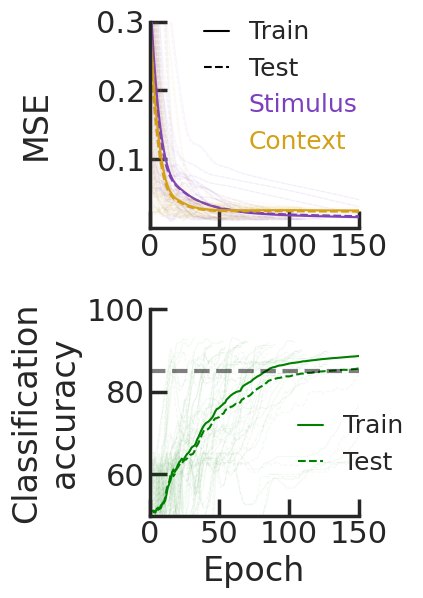

Final average train class acc: 0.908
Final average test class acc: 0.877


In [13]:
all_epochs = pd.concat([net['train_test_res_df'] for net in all_nets_detailed_res], ignore_index=True)
epoch2plot = 150

# for the mean curves, carry each converged net's final values forward so every epoch averages all 30 nets
# (otherwise converged nets drop out and the mean only reflects the slow, not-yet-converged ones)
max_ep = int(all_epochs['epoch'].max()) + 1
padded_epochs = pd.concat([net['train_test_res_df'].set_index('epoch').reindex(range(max_ep)).ffill().reset_index()
                           for net in all_nets_detailed_res], ignore_index=True)
mean_epochs = padded_epochs.groupby('epoch').mean()

fig, axs = plt.subplots(2, 1, figsize=(4.5,6.5)); axs, ax = axs.flatten(), 0
stim_loss_color, context_loss_color = '#7B3FBF', '#D4A017'

# losses: both are MSEs in squared-position units, so one shared axis. solid = train, dashed = test
axs[ax].set(ylabel='MSE\n',xlim=(0, epoch2plot),xticks=range(0, epoch2plot+1, 50),ylim=(0,.3),yticks=[.1, .2, .3])
for col, color, label in [('mse_losses', 'dodgerblue', 'stim_loss'), ('context_losses', 'orangered', 'context_loss')]:
    for _, grp in all_epochs.groupby('net_idx'):
        axs[ax].plot(grp['epoch'], grp[f'train_{col}'], '-',  color=stim_loss_color if col=='mse_losses' else context_loss_color, alpha=0.05, linewidth=0.8)
        axs[ax].plot(grp['epoch'], grp[f'test_{col}'],  '--', color=stim_loss_color if col=='mse_losses' else context_loss_color, alpha=0.05, linewidth=0.8)
    axs[ax].plot(mean_epochs.index, mean_epochs[f'train_{col}'], '-',  linewidth=1.5, color=stim_loss_color if col=='mse_losses' else context_loss_color, label=f'{label} train')
    axs[ax].plot(mean_epochs.index, mean_epochs[f'test_{col}'],  '--', linewidth=1.5, color=stim_loss_color if col=='mse_losses' else context_loss_color, label=f'{label} test')
# legend
from matplotlib.lines import Line2D
handles = [Line2D([0],[0],color='black',linestyle='-',lw=1.5,label='Train'), Line2D([0],[0],color='black',linestyle='--',lw=1.5,label='Test'), Line2D([0],[0],color='none',label='Stimulus'), Line2D([0],[0],color='none',label='Context')]
leg = axs[ax].legend(handles=handles,handlelength=1.0,fontsize=18,frameon=False,bbox_to_anchor=(.15,.25))
leg.get_texts()[2].set_color(stim_loss_color); leg.get_texts()[3].set_color(context_loss_color)
ax += 1

# classification accuracy (side-of-boundary, from the positional output)
axs[ax].set(xlabel='Epoch',ylabel='Classification\naccuracy',xlim=(0, epoch2plot),xticks=range(0, epoch2plot+1, 50),ylim=(0.5, 1), yticks=[.6, .8, 1])
for _, grp in all_epochs.groupby('net_idx'):
    axs[ax].plot(grp['epoch'], grp['train_class_acc'], '-',  color='green', alpha=0.05, linewidth=0.8)
    axs[ax].plot(grp['epoch'], grp['test_class_acc'],  '--', color='green', alpha=0.05, linewidth=0.8)
axs[ax].plot(mean_epochs.index, mean_epochs['train_class_acc'], '-',  linewidth=1.5, color='green', label='Train')
axs[ax].plot(mean_epochs.index, mean_epochs['test_class_acc'],  '--', linewidth=1.5, color='green', label='Test')
axs[ax].axhline(class_acc_target, color='black', linestyle='--', alpha=0.5)  # convergence target
axs[ax].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}'))
axs[ax].legend(handlelength=1.0,fontsize=18,frameon=False,bbox_to_anchor=(.6,.6))

plt.tight_layout()
plt.savefig('../../outputs/figs/presentations/ccn/poster/training_curves.svg', dpi=300, bbox_inches='tight')
plt.show()
print(f"Final average train class acc: {mean_epochs['train_class_acc'].iloc[-1]:.3f}"); print(f"Final average test class acc: {mean_epochs['test_class_acc'].iloc[-1]:.3f}")

response distributions

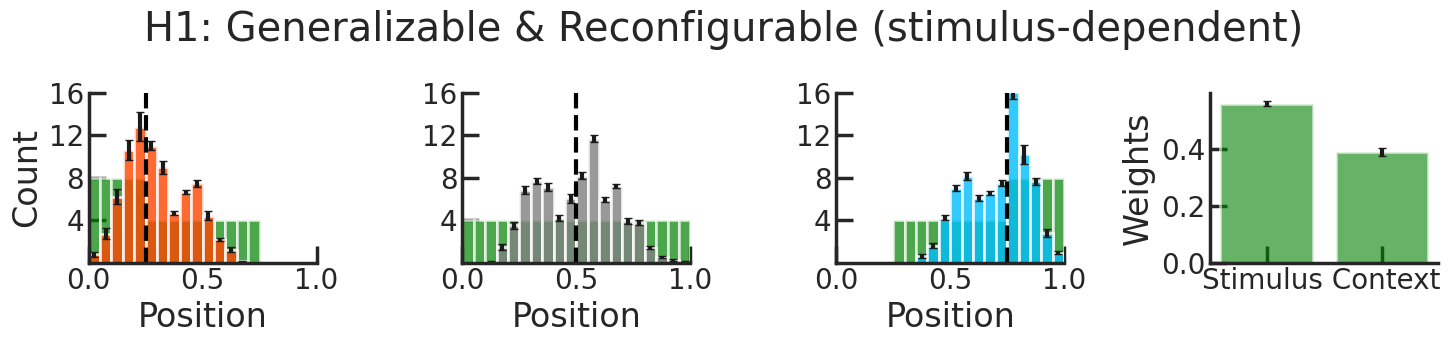

In [14]:
# collect all network predictions on eval set
inference_df = pd.concat([net['inference_df'].assign(net_idx=net['net_idx']) for net in all_nets_detailed_res], ignore_index=True)

fig, axs = plt.subplots(1, 4, figsize=(15,4)); axs, ax = axs.flatten(), 0
plt.suptitle(f'H1: {hypothesis} (stimulus-dependent)',y=.9)
# plt.suptitle(f'H2: {hypothesis} (context-dependent)',y=.9)
# plt.suptitle(f'H3: {hypothesis}',y=.9)
n_bins = 20; bin_centers = np.linspace(0, 1, n_bins, endpoint=False) + 0.5 / n_bins

# --- cols 1-3: stimulus vs response distributions, per context ---
for cond in conds:
    cond_df = inference_df[inference_df['condition'] == cond]
    axs[ax].set(xlabel='Position', ylabel='Count' if cond == conds[0] else '', xlim=(0, 1), ylim=(0,16),xticks=np.linspace(0,1,3), xticklabels=np.linspace(0,1,3), yticks=np.linspace(4, 16, 4))

    # stim
    mean_nets_stim_cts = np.histogram(cond_df['stim'], bins=n_bins, range=(0,1))[0] / n_nets
    axs[ax].bar(bin_centers, mean_nets_stim_cts, width=1/n_bins, color='green', alpha=0.7, capsize=3, label='stimulus')

    # response
    net_resp_cts = []
    for _, net_df in cond_df.groupby('net_idx'): net_resp_cts.append(np.histogram(net_df['pos_pred'], bins=n_bins, range=(0,1))[0])
    net_resp_cts = np.array(net_resp_cts)
    mean_nets_resp_cts = net_resp_cts.mean(0)
    sem_nets_resp_cts  = net_resp_cts.std(0) / np.sqrt(n_nets)
    axs[ax].bar(bin_centers, mean_nets_resp_cts, width=1/n_bins, color=['orangered','gray','deepskyblue'][ax], alpha=0.8, yerr=sem_nets_resp_cts, capsize=3, label='response')

    axs[ax].axvline(cond_df['boundary'].iloc[0], color='black', linestyle='--')
    axs[ax].set_xlabel('Position'); axs[ax].set_ylabel('Count' if ax == 0 else ''); axs[ax].tick_params(axis='both', labelsize=20)
    # if hypothesis=='Generalizable':
    #     axs[ax].text(.25,1,'Stim',color='green',ha='left',va='top',transform=axs[ax].transAxes)
    #     axs[ax].text(.25,.8,'Resp',color=['orangered','gray','deepskyblue'][ax],ha='left',va='top',transform=axs[ax].transAxes)
    axs[1].set_title(f'Stimulus & response distributions by context' if hypothesis=='Generalizable' else '', y=1.1)
    ax += 1

# --- col 4: regression weights, response ~ stimulus + context, per net ---
net_betas = [] # per net: [beta_stim, beta_context]
for _, net_df in inference_df.groupby('net_idx'):
    X = np.column_stack([np.ones(len(net_df)), net_df['stim'], net_df['boundary']])
    betas, *_ = np.linalg.lstsq(X, net_df['pos_pred'].values, rcond=None)
    net_betas.append(betas[1:]) # drop intercept
net_betas = np.array(net_betas) # (n_nets, 2)

axs[ax].set(title='Regression' if hypothesis=='Generalizable' else '',ylabel='Weights',xticks=[0, 1],xticklabels=['Stimulus ',' Context'])
means, sems = net_betas.mean(0), net_betas.std(0) / np.sqrt(n_nets)
axs[ax].bar([0, 1], means, color='green', alpha=0.6, yerr=sems, capsize=3)
axs[ax].tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.savefig(f'../../outputs/figs/presentations/ccn/poster/{hypothesis}.svg', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
inference_df

,condition,stim,boundary,cond_unique_stim_idx,class,trial_id,rep,stim_noised,train/test,pos_pred,class_pred,net_idx
0,base,0.025,0.50,0,0,0,9,-0.002915,eval,0.214006,0.0,0
1,base,0.025,0.50,0,0,0,12,0.069071,eval,0.256972,0.0,0
2,base,0.025,0.50,0,0,0,8,0.079710,eval,0.263322,0.0,0
3,base,0.025,0.50,0,0,0,1,-0.018644,eval,0.204619,0.0,0
4,base,0.075,0.50,1,0,1,9,0.103147,eval,0.277310,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7195,flat,0.975,0.75,14,1,58,1,1.059373,eval,0.890672,1.0,29
7196,flat,0.975,0.75,14,1,59,9,0.980103,eval,0.852386,1.0,29
7197,flat,0.975,0.75,14,1,59,12,1.222244,eval,0.969335,1.0,29
7198,flat,0.975,0.75,14,1,59,8,0.803405,eval,0.767045,1.0,29


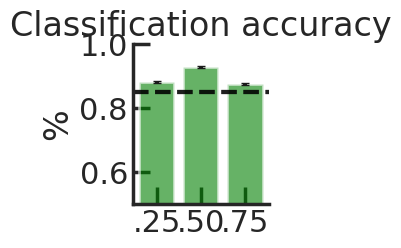

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.set(title=f'Classification accuracy', ylabel='%', ylim=(0.5, 1), yticks=[.6, .8, 1], xticks=[0, 1, 2], xticklabels=conds)

for i, cond in enumerate(conds):
    cond_df = inference_df[inference_df['condition'] == cond]
    net_accs = []
    for _, net_df in cond_df.groupby('net_idx'):
        net_accs.append((net_df['class_pred'] == net_df['class']).mean())
    net_accs = np.array(net_accs)
    mean_acc, sem = net_accs.mean(), net_accs.std() / np.sqrt(n_nets)
    ax.bar(i, mean_acc, color='green', alpha=0.6, yerr=sem, capsize=3)
    ax.axhline(class_acc_target, color='black', linestyle='--', alpha=0.5)

plt.tight_layout(); plt.show()

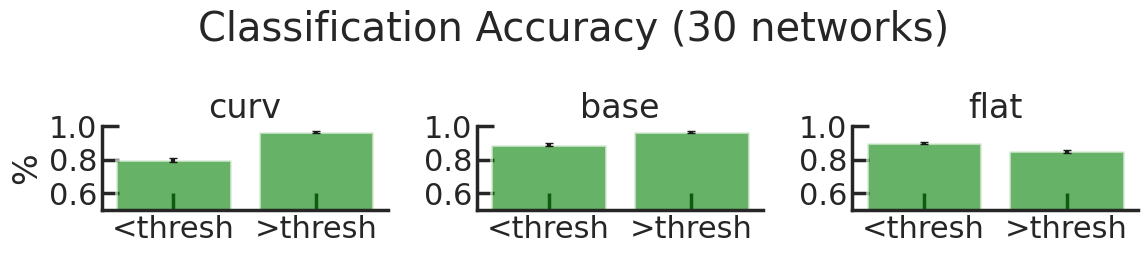

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(12,3)); axs, ax = axs.flatten(), 0
plt.suptitle(f'Classification Accuracy ({n_nets} networks)', y=.9)

for i, cond in enumerate(conds):
    cond_df = inference_df[inference_df['condition'] == cond]
    axs[ax].set(title=cond, ylabel='%' if cond == conds[0] else '', xlim=(-0.5, 1.5), ylim=(.5,1),xticks=[0, 1], xticklabels=['<thresh', '>thresh'], yticks=[.6, .8, 1])

    for category in [0, 1]: # get mean acc across nets for this category

        net_accs = [] # accuracy of each net for this category and condition
        for _, net_df in cond_df.groupby('net_idx'):
            category_df = net_df[net_df['class'] == category] # subset to this category
            net_accs.append((category_df['class_pred'] == category_df['class']).mean())

        net_accs = np.array(net_accs)
        mean_nets_acc, sem = net_accs.mean(), net_accs.std() / np.sqrt(n_nets)
        axs[ax].bar(category, mean_nets_acc, color='green', alpha=0.6, yerr=sem, capsize=3)

    ax += 1

plt.tight_layout(); plt.show()

### stimulus vs response
toggle between raw or aligned

In [18]:
inference_df['stim_aligned'] = inference_df['stim'] - inference_df['boundary']
inference_df['resp_aligned'] = inference_df['pos_pred'] - inference_df['boundary']

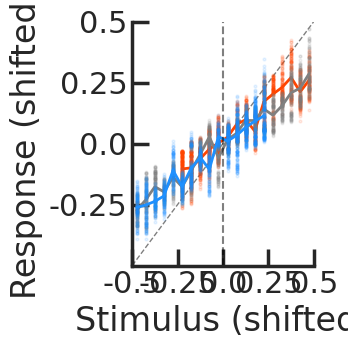

In [29]:
choice = ['raw', 'aligned'][1]
if choice == 'raw':
    stim_col, resp_col = 'stim', 'pos_pred'
    xlim, ylim = (0, 1), (0, 1)
    xticks, yticks = np.linspace(0, 1, 5), np.linspace(.25, 1, 4)
    xlabel, ylabel = 'Stimulus', 'Response'
elif choice == 'aligned':
    stim_col, resp_col = 'stim_aligned', 'resp_aligned'
    xlim, ylim = (-0.5, 0.5), (-0.5, 0.5)
    xticks, yticks = np.linspace(-0.5, 0.5, 5), np.linspace(-0.5, 0.5, 5)[1:]
    xlabel, ylabel = 'Stimulus (shifted)', 'Response (shifted)'

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
cond2color = {'C1': 'orangered', 'C2': 'gray', 'C3': 'dodgerblue'}
ax.set(xlabel=xlabel, ylabel=ylabel, xlim=xlim, ylim=ylim, xticks=xticks, yticks=yticks, xticklabels=xticks, yticklabels=yticks)
ax.plot(xlim, ylim, color='black', linewidth=1, linestyle='--', alpha=0.5)

for cond_i in range(len(conds)):
    cond, bound = conds[cond_i], bounds[cond_i]
    cond_df = inference_df[inference_df['condition'] == cond]

    ax.plot(cond_df[stim_col], cond_df[resp_col], 'o', markersize=2, alpha=0.1, color=cond2color[cond])
    if choice == 'raw': ax.axvline(bound, color=cond2color[cond], linestyle='--', alpha=0.6)

    mean_resp = cond_df.groupby(stim_col)[resp_col].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, label=cond, color=cond2color[cond])

if choice == 'aligned': ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)

plt.tight_layout()
# plt.savefig(f'../../outputs/figs/presentations/ccn/beh-net-stim_vs_resp{"_aligned" if choice == "aligned" else ""}.svg', format='svg')
plt.show()

### test for context-shifts

In [20]:
from itertools import combinations; from scipy.stats import ttest_rel

def between_ctx_mse(net_df, stim_col, resp_col):
    pair_mses = []
    for cond1, cond2 in combinations(conds, 2):
        cntxt1 = net_df[net_df['condition'] == cond1].groupby(stim_col)[resp_col].mean()
        cntxt2 = net_df[net_df['condition'] == cond2].groupby(stim_col)[resp_col].mean()
        shared = cntxt1.index.intersection(cntxt2.index)
        pair_mses.append(np.mean((cntxt1.loc[shared] - cntxt2.loc[shared]) ** 2))
    return np.mean(pair_mses)

net_ids = inference_df['net_idx'].unique()
raw_divergence     = np.array([between_ctx_mse(inference_df[inference_df['net_idx'] == n], 'stim',         'pos_pred')      for n in net_ids])
aligned_divergence = np.array([between_ctx_mse(inference_df[inference_df['net_idx'] == n], 'stim_aligned', 'resp_aligned') for n in net_ids])
print('Raw between-context MSE:    ', raw_divergence); print('Aligned between-context MSE:', aligned_divergence)

Raw between-context MSE:     [0.03584371 0.0126258  0.02416828 0.0250116  0.02866678 0.02091354
 0.01163091 0.02929502 0.0215891  0.02437943 0.03994399 0.02374788
 0.02755519 0.03399051 0.021355   0.01491664 0.01915408 0.01752832
 0.01301628 0.01178544 0.02233042 0.01552404 0.01468886 0.01432372
 0.014483   0.02547496 0.0174487  0.0201944  0.02312817 0.02682473]
Aligned between-context MSE: [0.00215656 0.00185413 0.00169532 0.00191783 0.0018632  0.00133642
 0.0031803  0.00223418 0.00131946 0.00169999 0.00133048 0.00167745
 0.00126701 0.00160364 0.00126718 0.00243415 0.00156151 0.00216773
 0.00372214 0.00372139 0.00184519 0.00278337 0.00212166 0.00239915
 0.00266999 0.00153105 0.00229724 0.0014603  0.00130587 0.00158698]


Paired t-test: t=14.026, p=1.87e-14


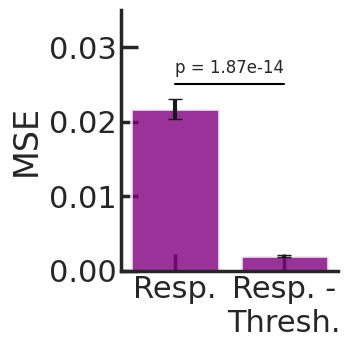

In [21]:
t_stat, p_val = ttest_rel(raw_divergence, aligned_divergence); print(f'Paired t-test: t={t_stat:.3f}, p={p_val:.3g}')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.set(xticks=[0, 1], xticklabels=['Resp.', 'Resp. -\nThresh.'], ylabel='MSE')

means = [raw_divergence.mean(), aligned_divergence.mean()]
sems  = [raw_divergence.std() / np.sqrt(len(raw_divergence)), aligned_divergence.std() / np.sqrt(len(aligned_divergence))]
ax.bar([0, 1], means, yerr=sems, capsize=5, color='purple', alpha=0.8)

line_y = max(m + s for m, s in zip(means, sems)) + 0.002
ax.plot([0, 1], [line_y, line_y], color='black', linewidth=1.5)
ax.text(0.5, line_y + 0.001, f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12); ax.set_ylim(0, line_y + 0.01)

plt.tight_layout()
# plt.savefig('../../outputs/figs/presentations/ccn/beh-net-context_divergence.svg', format='svg')
plt.show()

### 6. Check & save

In [22]:
print("inference_df columns:", inference_df.columns.tolist())
assert len(inference_df) == n_nets * len(eval_df), f"Expected {n_nets * len(eval_df)} rows in inference_df, got {len(inference_df)}"
print(f'len(inference_df) = n_nets * len(eval_df) = {len(inference_df)}')

inference_df.to_csv('../../outputs/simulations/inference_df.csv', index=False)
print('Saved: ../../outputs/simulations/inference_df.csv')

inference_df columns: ['condition', 'stim', 'boundary', 'cond_unique_stim_idx', 'class', 'trial_id', 'rep', 'stim_noised', 'train/test', 'pos_pred', 'class_pred', 'net_idx', 'stim_aligned', 'resp_aligned']
len(inference_df) = n_nets * len(eval_df) = 7200
Saved: ../../outputs/simulations/inference_df.csv


In [23]:
hidden_stack = np.stack([nr['inference_hidden_arr'] for nr in all_nets_detailed_res], axis=0)
print(f'hidden_stack (n_nets, n_infer_trials, n_hidden_units): {hidden_stack.shape}')
# assert no NaNs or infs in hidden activations
assert not np.isnan(hidden_stack).any(), "Hidden activations contain NaN values."
assert not np.isinf(hidden_stack).any(), "Hidden activations contain inf values."

np.save('../../outputs/simulations/hidden_stack.npy', hidden_stack)   # shape (30, 60, 10)
print("Saved: ../../outputs/simulations/hidden_stack.npy")

hidden_stack (n_nets, n_infer_trials, n_hidden_units): (30, 240, 10)
Saved: ../../outputs/simulations/hidden_stack.npy


### POSTER PLOTS

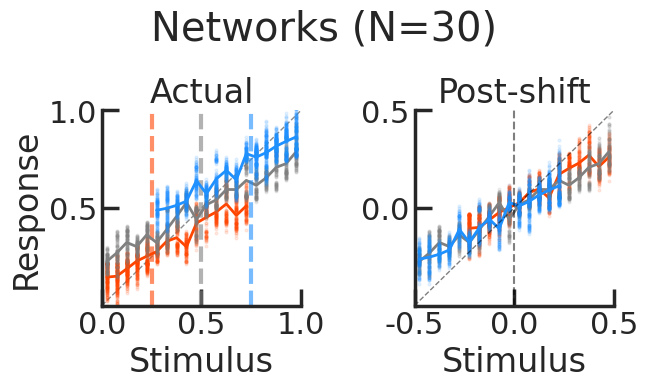

In [24]:
# ============================================================================
# POSTER — NETWORKS: 1x2
#   col 1: response vs stimulus, by context
#   col 2: response vs stimulus, context-aligned (shifted by boundary)
# Reuses in-memory inference_df.
# ============================================================================
cond2color = {'C1': 'orangered', 'C2': 'gray', 'C3': 'dodgerblue'}

# context-aligned cols, in case the cells above weren't run this session
inference_df['stim_aligned'] = inference_df['stim'] - inference_df['boundary']
inference_df['resp_aligned'] = inference_df['pos_pred'] - inference_df['boundary']

fig, axs = plt.subplots(1, 2, figsize=(7,4.5))
fig.suptitle(f'Networks (N={n_nets})',y=.9)

ax = axs[0]
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
for cond, bound in zip(conds, bounds):
    cond_df = inference_df[inference_df['condition'] == cond]
    ax.plot(cond_df['stim'], cond_df['pos_pred'], 'o', markersize=2, alpha=0.1, color=cond2color[cond])
    ax.axvline(bound, color=cond2color[cond], linestyle='--', alpha=0.6)
    mean_resp = cond_df.groupby('stim')['pos_pred'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, color=cond2color[cond], label=cond)
ax.set(title='Actual',xlabel='Stimulus',ylabel='Response',xlim=(0, 1),ylim=(0, 1),xticks=np.linspace(0,1,3),xticklabels=np.linspace(0,1,3),yticks=np.linspace(0,1,3)[1:],yticklabels=np.linspace(0,1,3)[1:])

ax = axs[1]
for cond in conds:
    cond_df = inference_df[inference_df['condition'] == cond]
    ax.plot(cond_df['stim_aligned'], cond_df['resp_aligned'], 'o', markersize=2, alpha=0.1, color=cond2color[cond])
    mean_resp = cond_df.groupby('stim_aligned')['resp_aligned'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, color=cond2color[cond], label=cond)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ax.plot([-0.5, 0.5], [-0.5, 0.5], color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set(title='Post-shift',xlabel='Stimulus',xlim=(-0.5, 0.5),ylim=(-0.5,0.5),xticks=np.linspace(-0.5,0.5,3),xticklabels=np.linspace(-0.5,0.5,3),yticks=np.linspace(-0.5,0.5,3)[1:],yticklabels=np.linspace(-0.5,0.5,3)[1:])

plt.tight_layout()
plt.savefig('../../outputs/figs/presentations/ccn/poster/net_stim_vs_resp.svg', format='svg')
plt.show()